# Extracting Real Next-Token Probabilities (Oil & Gas Text Watermarking Demo)

**Educational simulation of keyed statistical text watermarking. This is not Anthropic's proprietary implementation.**

## Section 1 — Project purpose

This notebook obtains **actual next-token probability distributions** from an open-weight language model (Qwen), using realistic oil and gas drilling/completions prompts.

A few things to be clear about up front:

- The probabilities in this notebook come from **Qwen**, not Claude, and not any Anthropic model.
- The *watermarking* demonstrated later (in the companion Mathematica notebook) is a **simulation** — a pedagogical, keyed reweighting scheme built for this project. It does not reproduce Anthropic's proprietary watermarking algorithm, keys, detector, thresholds, or Claude's probability distributions.
- LLMs operate on **tokens**, not necessarily complete words. A single English word can split into multiple tokens, and a token string often contains a **leading space** or is a subword fragment (e.g. `" circ"` + `"ulated"`).

The pipeline for this notebook is:

```
prompt -> model -> logits -> softmax -> real next-token probabilities -> JSON export
```

## Section 2 — Configuration

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.model_utils import get_device, load_model_and_tokenizer
from src.extraction import (
    get_next_token_distribution,
    extract_all_prompts,
    export_distributions,
    generate_sequence,
)
from src.validation import validate_export

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Default model. To use the larger 7B variant instead, change this to:
#   MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

TOP_K = 15
OUTPUT_PATH = "../data/processed/next_token_distributions.json"

In [3]:
# Fixed list of oil & gas drilling/completions prompts. Each prompt ends right before an
# infinitive or list-continuation point (e.g. "...began to", "...and"), which structurally
# forces the next word to be a concrete action verb rather than a generic filler/modal word
# like "the" or "should".
PROMPTS = [
    ("P01", "The crew circulated the well clean and prepared to"),
    ("P02", "After the packer was set, the operator continued to"),
    ("P03", "With TD reached, the drilling team began to"),
    ("P04", "The liner was run to depth, and the crew immediately"),
    ("P05", "Once cement was pumped and displaced, the team continued to"),
    ("P06", "The pressure test held, so the crew prepared to"),
    ("P07", "The wellhead was nippled up, and the operator started to"),
    ("P08", "After pulling the BHA to surface, the crew began to"),
    ("P09", "The BOP was function tested, and the crew then"),
    ("P10", "The pill was spotted across the zone, and the operator prepared to"),
    # A generic/unconstrained vs. a highly constrained technical prompt, added to compare how
    # much "room" the next-token distribution actually has in each register -- see Presentation
    # Mode section "Technical Language Constrains Token Choice" in the Mathematica notebook.
    ("PGEN", "It was a pleasant afternoon, and the children decided to"),
    ("PTECH", "Pressure test the tubing to 5,000 psi for 15"),
    # A safety-critical "which specific number" decision point, added because the earlier
    # illustrative example (Presentation Mode Section 5) had normal and watermarked selections
    # land on the same word by default -- no visible consequence. This prompt asks the model to
    # choose the leading digit of a BOP test pressure, where real Qwen candidates spread across
    # several plausible leading digits (1/2/3/7/...) rather than converging on one -- a
    # materially different, safety-relevant answer depending on which digit is chosen, and one
    # where the simulated watermark demonstrably does flip the top pick at higher strength.
    ("PSAFETY", "The BOP was tested to a pressure of "),
]

print(f"Configured {len(PROMPTS)} prompts, TOP_K={TOP_K}, model={MODEL_NAME}")

Configured 13 prompts, TOP_K=15, model=Qwen/Qwen2.5-1.5B-Instruct


## Section 3 — Load tokenizer and model

No remote inference API is used — the model runs locally after the first download/cache. Device selection prefers MPS (Apple Silicon) > CUDA > CPU; CUDA is never hard-coded.

In [4]:
model, tokenizer, device = load_model_and_tokenizer(MODEL_NAME)

print(f"Model name        : {MODEL_NAME}")
print(f"Selected device   : {device}")
print(f"Vocabulary size   : {tokenizer.vocab_size}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model name        : Qwen/Qwen2.5-1.5B-Instruct
Selected device   : mps
Vocabulary size   : 151643


## Section 4 — Inspect tokenization

Before extracting probabilities, it's worth seeing how the tokenizer actually splits a prompt. Words like *"circulated"* or *"pressure-test"* may not correspond to a single token — they can be built from several subword pieces.

In [5]:
example_prompt = "The crew circulated the well clean and prepared to"

token_ids = tokenizer(example_prompt)["input_ids"]
decoded_tokens = [tokenizer.decode([tid]) for tid in token_ids]

print(f"Prompt: {example_prompt!r}")
print(f"Number of input tokens: {len(token_ids)}")
print()
for tid, tok in zip(token_ids, decoded_tokens):
    print(f"  token_id={tid:<8} token={tok!r}")

Prompt: 'The crew circulated the well clean and prepared to'
Number of input tokens: 9

  token_id=785      token='The'
  token_id=13627    token=' crew'
  token_id=62873    token=' circulated'
  token_id=279      token=' the'
  token_id=1632     token=' well'
  token_id=4240     token=' clean'
  token_id=323      token=' and'
  token_id=10030    token=' prepared'
  token_id=311      token=' to'


## Section 5 — Extract next-token logits

The reusable extraction function lives in `src/extraction.py` (`get_next_token_distribution`). It:

1. tokenizes the prompt,
2. runs the model under `torch.no_grad()`,
3. takes `outputs.logits[0, -1, :]` (the logits for the *next* token),
4. applies softmax,
5. extracts the top-k probabilities and token IDs,
6. decodes each token individually,
7. returns a structured result.

Each candidate has the shape `{rank, token_id, token, probability, logit}`. Stored values are not rounded excessively.

In [6]:
demo_distribution = get_next_token_distribution(model, tokenizer, example_prompt, top_k=TOP_K)

print(f"Input token count: {demo_distribution['input_token_count']}")
print()
for c in demo_distribution["candidates"][:5]:
    print(c)

Input token count: 9

{'rank': 1, 'token_id': 1191, 'token': ' start', 'probability': 0.080322265625, 'logit': 18.5625}
{'rank': 2, 'token_id': 3271, 'token': ' move', 'probability': 0.050262451171875, 'logit': 18.09375}
{'rank': 3, 'token_id': 728, 'token': ' go', 'probability': 0.03509521484375, 'logit': 17.734375}
{'rank': 4, 'token_id': 1968, 'token': ' head', 'probability': 0.031463623046875, 'logit': 17.625}
{'rank': 5, 'token_id': 3161, 'token': ' begin', 'probability': 0.0273284912109375, 'logit': 17.484375}


## Section 6 — Run all prompts

Runs the extraction function for every configured prompt and assembles the result object (`metadata` + `prompts`). 

Note: top-k probabilities will generally **not** sum to 1, since they are only the top-k subset of the full vocabulary distribution. They are not renormalized here.

In [7]:
prompt_results = extract_all_prompts(model, tokenizer, PROMPTS, top_k=TOP_K)

result = {
    "metadata": {
        "model": MODEL_NAME,
        "top_k": TOP_K,
        "device": str(device),
        "description": "Real next-token probabilities extracted from an open-weight model "
                        "for educational watermarking demonstrations.",
        "watermarking": "not applied in Python extraction stage",
    },
    "prompts": prompt_results,
}

In [8]:
# Validate: descending probabilities, valid [0, 1] range, sequential ranks, expected candidate count.
validate_export(result)
print("All validation checks passed:")
print("  - top-k probabilities are descending")
print("  - every probability is between 0 and 1")
print("  - ranks are sequential")
print("  - all prompts have the expected number of candidates")

All validation checks passed:
  - top-k probabilities are descending
  - every probability is between 0 and 1
  - ranks are sequential
  - all prompts have the expected number of candidates


## Section 7 — Generate one real example continuation

Everything above extracts a single next-token distribution per prompt. For the Mathematica notebook's "colored paragraph" view, it's useful to also have a short **real, multi-step continuation**: starting from one seed prompt, repeatedly take the model's own top-1 token and append it, recording the full top-k distribution at every step along the way.

This is genuine greedy decoding (deterministic, always taking the model's own highest-probability token) — not random sampling, and not yet watermarked in any way. It gives the Mathematica notebook real per-word probabilities to compare against a simulated watermark, word by word, later.

In [9]:
GENERATION_SEED_PROMPT = "After reaching TD, the crew began to"
GENERATION_STEPS = 8

generation_result = generate_sequence(
    model, tokenizer, GENERATION_SEED_PROMPT, num_steps=GENERATION_STEPS, top_k=TOP_K
)

full_text = GENERATION_SEED_PROMPT + "".join(s["chosen_token"] for s in generation_result["steps"])
print("Seed prompt      :", GENERATION_SEED_PROMPT)
print("Generated text    :", full_text)
print()
for s in generation_result["steps"]:
    top3 = ", ".join(f"{c['token']!r} ({c['probability']:.1%})" for c in s["candidates"][:3])
    print(f"  step {s['step']}: chose {s['chosen_token']!r:12}  top-3: {top3}")

Seed prompt      : After reaching TD, the crew began to
Generated text    : After reaching TD, the crew began to experience a series of issues. The first

  step 1: chose ' experience'  top-3: ' experience' (4.5%), ' execute' (2.4%), ' perform' (2.2%)
  step 2: chose ' a'          top-3: ' a' (21.5%), ' an' (4.5%), ' the' (2.3%)
  step 3: chose ' series'     top-3: ' series' (9.2%), ' loss' (8.4%), ' rapid' (6.1%)
  step 4: chose ' of'         top-3: ' of' (99.8%), ' a' (0.0%), '\n' (0.0%)
  step 5: chose ' issues'     top-3: ' issues' (9.9%), ' problems' (7.0%), ' symptoms' (4.7%)
  step 6: chose '.'           top-3: '.' (27.4%), ',' (20.4%), ' with' (16.4%)
  step 7: chose ' The'        top-3: ' The' (28.1%), ' Which' (11.5%), ' They' (7.0%)
  step 8: chose ' first'      top-3: ' first' (9.6%), ' crew' (9.1%), ' aircraft' (5.8%)


## Section 8 — Visual inspection

Horizontal bar charts of the top-k next-token probabilities for several representative prompts.

In [10]:
def plot_top_k(prompt_entry, top_k_to_show=10):
    candidates = prompt_entry["candidates"][:top_k_to_show]
    tokens = [repr(c["token"]) for c in candidates][::-1]
    probs = [c["probability"] for c in candidates][::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(tokens, probs)
    ax.set_xlabel("Probability")
    ax.set_title(f"Prompt: {prompt_entry['prompt']!r}")
    for i, p in enumerate(probs):
        ax.text(p, i, f" {p:.1%}", va="center")
    fig.tight_layout()
    plt.show()

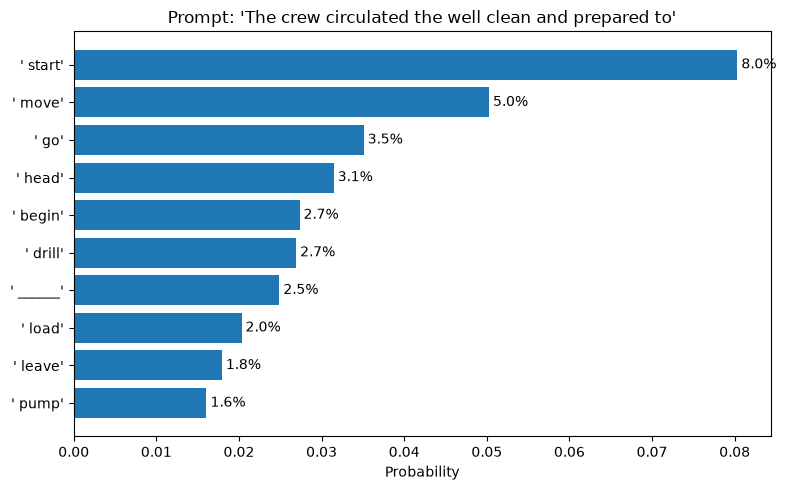

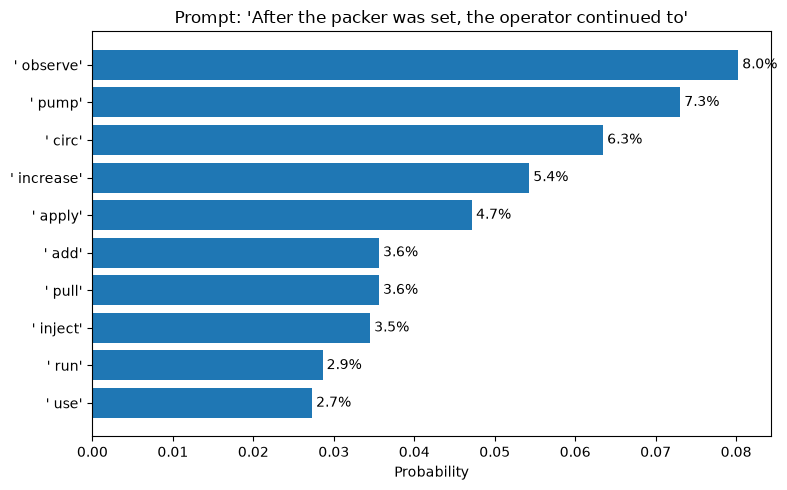

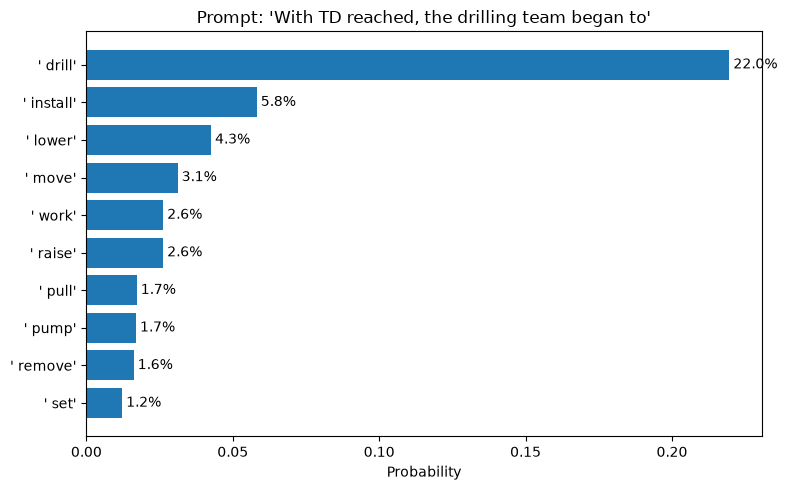

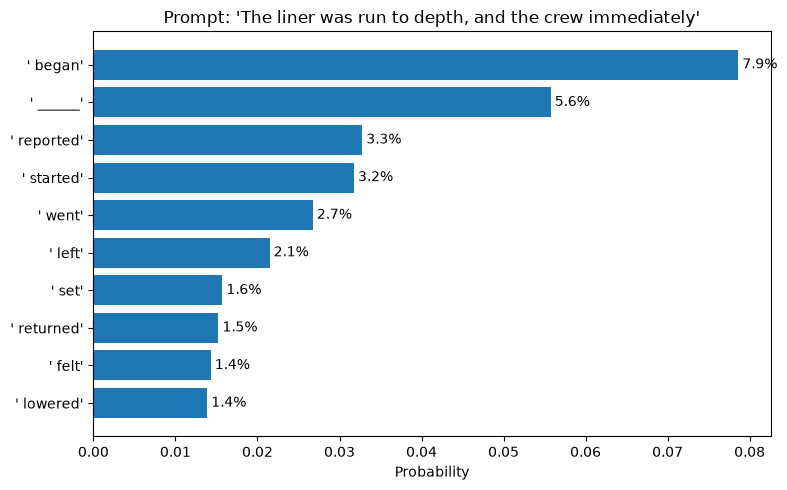

In [11]:
for prompt_entry in prompt_results[:4]:
    plot_top_k(prompt_entry)

## Section 9 — Export

Writes the full result to `data/processed/next_token_distributions.json` as UTF-8, preserving token strings (including leading whitespace) exactly as decoded. Top-k probabilities are exported as-is, not renormalized. Includes the real example continuation from Section 7 under the `"generation"` key.

In [12]:
exported = export_distributions(
    OUTPUT_PATH, MODEL_NAME, TOP_K, device, prompt_results,
    generation=generation_result,
)

print(f"Output path : {OUTPUT_PATH}")
print(f"Prompts     : {len(exported['prompts'])}")
print(f"Top-k size  : {exported['metadata']['top_k']}")
print(f"Model name  : {exported['metadata']['model']}")
print(f"Generation  : seed={exported['generation']['seed_prompt']!r}, steps={len(exported['generation']['steps'])}")

Output path : ../data/processed/next_token_distributions.json
Prompts     : 13
Top-k size  : 15
Model name  : Qwen/Qwen2.5-1.5B-Instruct
Generation  : seed='After reaching TD, the crew began to', steps=8


## Section 10 — Summary

**Python stage** (this notebook):

```
prompt -> model -> logits -> softmax -> real next-token probabilities
```

**Mathematica stage** (`02_oil_gas_text_watermarking.nb`):

```
real next-token probabilities -> simulated keyed sampling -> statistical watermark experiment
```

The JSON exported above (`data/processed/next_token_distributions.json`) is the handoff point between the two stages. Nothing about watermarking has been applied yet — that happens next, entirely inside the Mathematica notebook, and is clearly labelled there as a simulation.